In [1]:
import numpy as np
import time

from src.simulation import Simulation
from src.layers import update_from_arrays
from src.plot.plot_tools import plot_layered_config
from src.config import Config
from src.builders import build_problem
from src.noise import add_noise_snr
from src.layers import create_layers_from_interfaces
from src.misfit import l2_misfit
from src.plot.plot_tools import set_plot_style
set_plot_style()
# 10Hz, 8 recvs, 600->2000

In [2]:
config = Config(n_receivers=8, x_min=600., x_max=2000.,
                   z_rec=50., z_src=20., x_src=50., nq_prop=256, f0=10., nq_evan=256, kx_max_factor=6,
                   total_time=2.0, delay=0.2, epsilon=1.25, free_surface=False, nfft_pad_factor=1, source_deriv=True)
param, acq = build_problem(config)
dxr = acq.xr[1] - acq.xr[0]
dt = param.dt
seed = 42
rng = np.random.default_rng(seed)
print(dt)
print(len(param.time))
save_figs = False
path_figs = ''

0.00625
321


In [3]:
vps = np.array([1500.0, 2700.0, 3200.0]) # 1800, 3200, or 2200, 3000
vp_ref = np.array([vps[1], vps[2]])
z_int = np.array([0.0, 100., 250., 400.])
rhos = np.array([2000.0, 2000.0, 2000.0])
layers = create_layers_from_interfaces(z_int, vps, rhos)

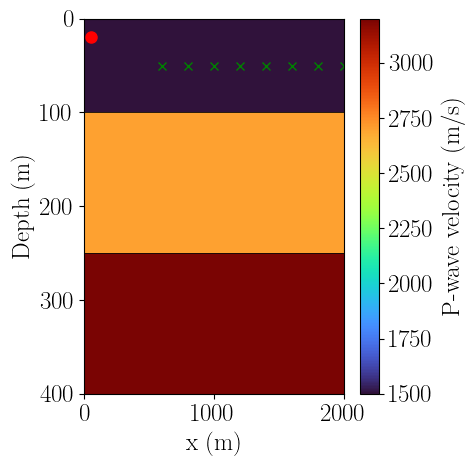

In [4]:
plot_layered_config(layers, xrecvs=acq.xr, zrecvs=config.z_rec, xs=[config.x_src, config.z_src], param='vp', cmap='turbo')

In [12]:
# generate observations
sim = Simulation(config)
d_obs = sim.forward(layers)
d_obs_noise, std_noise = add_noise_snr(d_obs, snr_db=10, seed=seed)
print(std_noise)

0.06690422545032707


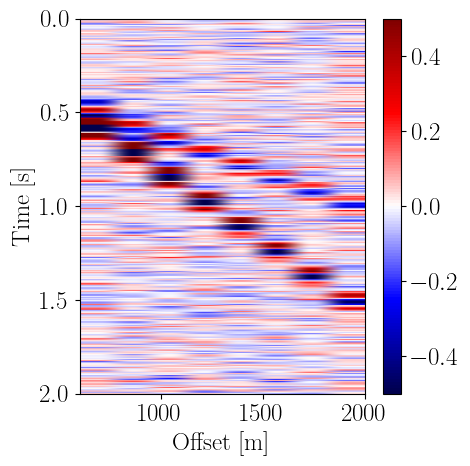

In [13]:
from src.plot.plot_tools import plot_seismogram
plot_seismogram(d_obs_noise.T, acq.xr, param.time, vmin=-0.5, vmax=0.5, ncolors=128, figsize=(5,5))

misfit = 1300.7804199547277


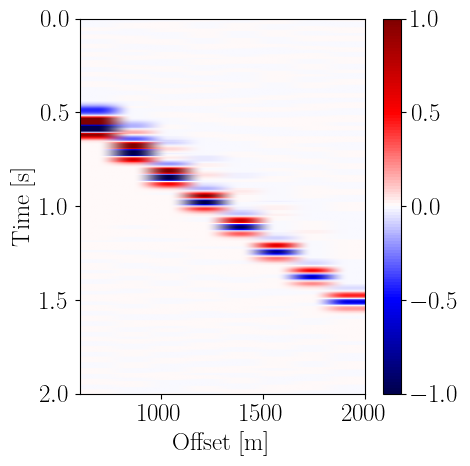

misfit = 2428.558099135686


In [14]:
L2_Err = l2_misfit(d_obs_noise, d_obs, std_noise=float(std_noise))
print("misfit =", L2_Err)
lays = create_layers_from_interfaces(z_int, np.array([1500., 2200., 2000.]), rhos)
d_cal = sim.forward(lays) #/ scale
plot_seismogram(d_cal.T, acq.xr, param.time, vmin=-1., vmax=1., ncolors=128, figsize=(5,5))
print("misfit =", l2_misfit(d_obs_noise, d_cal, std_noise=float(std_noise)))

In [15]:
lays = create_layers_from_interfaces(z_int, np.array([1500., 2900., 1000.]), rhos)
d_cal = sim.forward(lays)
print("misfit =", l2_misfit(d_obs_noise, d_cal, std_noise=float(std_noise)))
lays = create_layers_from_interfaces(z_int, np.array([1500., 4000., 800.]), rhos)
d_cal = sim.forward(lays)
print("misfit =", l2_misfit(d_obs_noise, d_cal, std_noise=float(std_noise)))

misfit = 2310.3283820627903
misfit = 2134.9799771579696


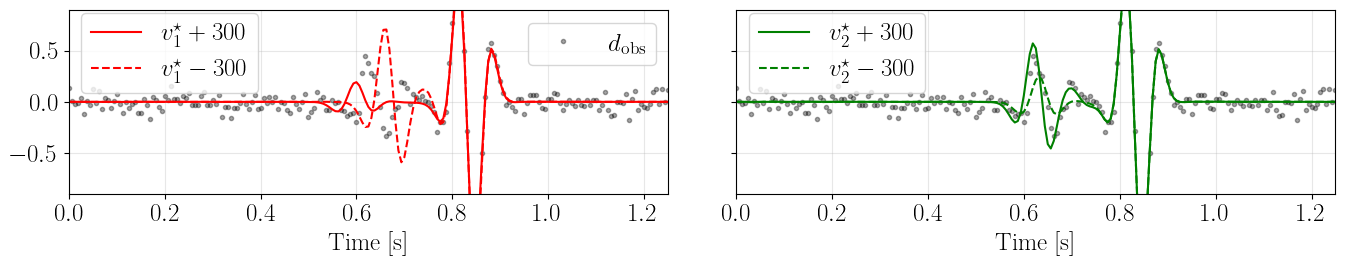

In [16]:
import matplotlib.pyplot as plt

v1_ref, v2_ref, v3_ref = 1500.0, 2700.0, 3200.0
dv = 300.0
indr = 2  # Receiver index

# --- 3. Compute Left Figure Data (Perturbing v1) ---
lays_v1_plus = create_layers_from_interfaces(z_int, np.array([v1_ref, v2_ref + dv, v3_ref]), rhos)
lays_v1_minus = create_layers_from_interfaces(z_int, np.array([v1_ref, v2_ref - dv, v3_ref]), rhos)
d_v1_plus = sim.forward(lays_v1_plus) #/ scale
d_v1_minus = sim.forward(lays_v1_minus) #/ scale
# --- 4. Compute Right Figure Data (Perturbing v2) ---
lays_v2_plus = create_layers_from_interfaces(z_int, np.array([v1_ref, v2_ref, v3_ref + dv]), rhos)
lays_v2_minus = create_layers_from_interfaces(z_int, np.array([v1_ref, v2_ref, v3_ref - dv]), rhos)
d_v2_plus = sim.forward(lays_v2_plus) #/ scale
d_v2_minus = sim.forward(lays_v2_minus) #/ scale

# --- 5. Plotting Side-by-Side ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 3.), sharey=True)
time1 = sim.param.time

line_obs, = ax1.plot(time1, d_obs_noise[0, indr, :], marker='.', color='black', ls=' ',alpha=0.35, markersize=6, label=r'$d_{\mathrm{obs}}$')
line_plus, = ax1.plot(time1, d_v1_plus[0, indr, :], 'r-', label=r'$v_1^\star + 300$')
line_minus, = ax1.plot(time1, d_v1_minus[0, indr, :], 'r--', label=r'$v_1^\star - 300$') # Fixed label to minus
ax1.set_xlabel('Time [s]')
ax1.set_xlim([0., 1.25])
ax1.set_ylim([-0.9, 0.9])
ax1.grid(True, alpha=0.3)
leg1 = ax1.legend(handles=[line_obs], loc='upper right')
ax1.add_artist(leg1)
ax1.legend(handles=[line_plus, line_minus], loc='upper left', bbox_to_anchor=(0.0, 1.05))

# --- Right Plot: v2 Perturbations ---
ax2.plot(time1, d_obs_noise[0, indr, :], marker='.', ls=' ', color='black', alpha=0.35, markersize=6)
ax2.plot(time1, d_v2_plus[0, indr, :], 'g-', label=r'$v_2^\star + 300$')
ax2.plot(time1, d_v2_minus[0, indr, :], 'g--', label=r'$v_2^\star - 300$')
ax2.set_xlabel('Time [s]')
ax2.legend(loc='upper left', bbox_to_anchor=(0.0, 1.05))
ax2.set_xlim([0., 1.25])
ax2.set_ylim([-0.9, 0.9])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
if save_figs:
    plt.savefig(path_figs+'data_toyxdac.pdf', dpi=300, bbox_inches='tight')
    plt.close()
else:
    plt.show()

In [12]:
lays = create_layers_from_interfaces(z_int, np.array([1500., 1800., 3200.]), rhos)
d_cal = sim.forward(lays)
cc = l2_misfit(d_obs_noise, d_cal, std_noise=float(std_noise))
n = d_cal.size
resi = np.sum(((d_obs_noise-d_cal) / std_noise) ** 2)
cost = np.sum(((d_obs_noise-d_cal)) ** 2)
ll = - cc - 0.5 * n * np.log(2.0 * np.pi * float(std_noise)**2)
print(std_noise)
print(ll/n)

print(d_cal[0].shape)

0.06690422545032707
-2.609693202323452
(8, 321)


In [13]:
vp_min, vp_max, npts = 800, 4500, 120
vp_min2, vp_max2 = 800, 4500

x_vals = np.linspace(vp_min, vp_max, npts)
y_vals = np.linspace(vp_min2, vp_max2, npts)
xgrid, ygrid = np.meshgrid(x_vals, y_vals, indexing='ij')
COST = np.empty_like(xgrid)

start_time = time.time()
for i in range(npts):
    for j in range(npts):
        point = np.array([xgrid[i, j], ygrid[i, j]])
        VP = np.array([vps[0], point[0], point[1]])
        layers = update_from_arrays(layers, vps=VP)
        d_cal = sim.forward(layers)
        COST[i,j] = l2_misfit(d_cal, d_obs_noise, std_noise=float(std_noise))

elapsed_time = time.time() - start_time
print(f"generated misfit map in {elapsed_time:.3f} seconds.")
print(f"time per forward is {elapsed_time/(npts*npts):.3f} seconds.")

generated misfit map in 798.252 seconds.
time per forward is 0.055 seconds.


In [14]:
vp_min, vp_max, npts = 900, 4400, 13
vp_min2, vp_max2 = 900, 4400

x_vals = np.linspace(vp_min, vp_max, npts)
y_vals = np.linspace(vp_min2, vp_max2, npts)
xgrid2, ygrid2 = np.meshgrid(x_vals, y_vals, indexing='ij')
GRADV1 = np.empty_like(xgrid2)
GRADV2 = np.empty_like(xgrid2)

start_time = time.time()
for i in range(npts):
    for j in range(npts):
        point = np.array([xgrid2[i, j], ygrid2[i, j]])
        VP = np.array([vps[0], point[0], point[1]])
        layers = update_from_arrays(layers, vps=VP)
        d_cal = sim.forward(layers)
        gradvp, _, _ = sim.gradient(residual= d_cal[0] - d_obs_noise[0], layers=layers)
        GRADV1[i,j] = gradvp[1]
        GRADV2[i,j] = gradvp[2]

elapsed_time = time.time() - start_time
print(f"generated misfit map in {elapsed_time:.3f} seconds.")
print(f"time per forward is {elapsed_time/(npts*npts):.3f} seconds.")

generated misfit map in 33.390 seconds.
time per forward is 0.198 seconds.


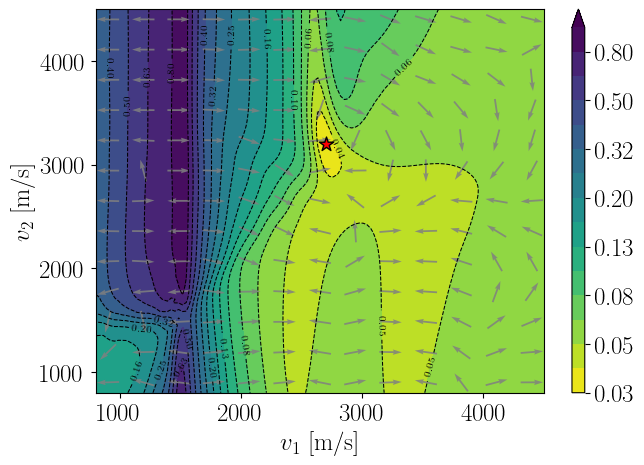

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from matplotlib.ticker import FixedLocator, FormatStrFormatter

X = xgrid
Y = ygrid
X2 = xgrid2
Y2 = ygrid2
# ---------------------------------------------------------
# Normalize gradient arrows for visualization
# ---------------------------------------------------------
Gx = -GRADV1
Gy = -GRADV2
norm = np.sqrt(Gx**2 + Gy**2)
# Avoid division by zero
norm[norm == 0] = 1.0
Gx_n = Gx / norm
Gy_n = Gy / norm
fig, ax = plt.subplots(figsize=(7, 5))
min_C = np.min(COST / np.max(COST))
# Cost contours
contour_lines = ax.contour(
    X,
    Y,
    COST / np.max(COST),
    levels=np.geomspace(min_C, 1., 16),
    colors="black",
    linewidths=0.75,
    linestyles="dashed",
)
ax.clabel(contour_lines, inline=True, fontsize=7, fmt="%.2f")
cf = ax.contourf(
    X,
    Y,
    COST / np.max(COST),
    levels=np.geomspace(min_C, 1., 16),
    norm=LogNorm(vmin=min_C, vmax=1.),
    cmap="viridis_r",
    extend="max",
)
ax.quiver(
    X2,
    Y2,
    Gx_n,
    Gy_n,
    color="gray",
    alpha=0.85,
    pivot="mid",
    angles="uv",
    scale=20,
    width=0.004,
)
# True/current model
ax.scatter(
    vps[1],
    vps[2],
    s=115,
    c="red",
    marker="*",
    alpha=1,
    edgecolors="k",
)
ax.set_xlabel(r"$v_1$ [m/s]")
ax.set_ylabel(r"$v_2$ [m/s]")
ax.set_xlim([800, 4500])
ax.set_ylim([800, 4500])

cbar = fig.colorbar(cf, aspect=30)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.tight_layout()
if save_figs:
    plt.savefig(path_figs+'Cost_and_gradient.pdf', dpi=300, bbox_inches='tight')
    plt.close()
else:
    plt.show()

In [16]:
from scipy.linalg import cho_factor, cho_solve
def log_prior(model, mu , cov):
    """Calculates ln p(m) for a Gaussian prior."""
    c, low = cho_factor(cov)
    inv_cov = cho_solve((c, low), np.eye(mu.size))
    prior_logdet = 2 * np.sum(np.log(np.diag(c)))
    diff = model - mu
    log_prior = -0.5 * (
        diff @ inv_cov @ diff + prior_logdet + mu.size * np.log(2.0 * np.pi)
    )
    return log_prior

In [17]:
from src.utilities import estimate_neff
mu1 = np.array([2500., 2500.])
Sigma1 = np.diag([600**2, 600**2])
vp_min, vp_max, npts = 800, 4500, 120
vp_min2, vp_max2 = 800, 4500

x_vals = np.linspace(vp_min, vp_max, npts)
y_vals = np.linspace(vp_min2, vp_max2, npts)
xgrid, ygrid = np.meshgrid(x_vals, y_vals, indexing='ij')

LOGPRIOR = np.empty_like(xgrid)
start_time = time.time()
for i in range(npts):
    for j in range(npts):
        point = np.array([xgrid[i, j], ygrid[i, j]])
        model = np.array([point[0], point[1]])
        LOGPRIOR[i,j] = log_prior(model, mu1, Sigma1)
elapsed_time = time.time() - start_time
print(f"generated prior in {elapsed_time:.3f} seconds.")

generated prior in 0.407 seconds.


In [22]:
LOGPOST = np.empty_like(xgrid)
LOGLIKE = np.empty_like(xgrid)
n = d_obs_noise.size
LOGLIKE = - COST - 0.5 * n * np.log(2.0 * np.pi * float(std_noise)**2)
result = estimate_neff(d_obs[0])
print(result)
beta = sim.param.dt / config.total_time
# n = Nt * nr
LOGLIKE = beta * LOGLIKE
LOGPOST = LOGLIKE + LOGPRIOR

{'n_eff': np.float64(604.2043366255862), 'n_eff_time': np.float64(80.84933794295058), 'n_eff_receivers': np.float64(7.473213164119273), 'tau_time': np.float64(3.9703479109069026), 'tau_space': np.float64(1.0704900053446835)}


In [19]:
i, j = np.unravel_index(np.argmax(LOGPOST), LOGPOST.shape)
v1_max, v2_max = X[i, j], Y[i, j]
print(v1_max)
print(v2_max)

2696.638655462185
3131.9327731092435


In [20]:
from matplotlib.gridspec import GridSpec
def posterior_with_marginals(
    X,
    Y,
    LOGPOST,
    vp_ref1,
    vp_ref2,
    cmap="Blues",
    save_fig=False,
):
    dv = X[1][0] - X[0][0]
    cell_area = dv * dv
    x_vals = X[:, 0]
    y_vals = Y[0, :]

    # 2. Compute TRUE Log Z without destroying the scale
    max_logpost = np.max(LOGPOST)
    print(max_logpost)
    scaled_post = np.exp(LOGPOST - max_logpost)
    # Total unnormalized volume
    Z_unscaled = np.sum(scaled_post) * cell_area
    print(Z_unscaled)
    log_Z_grid = max_logpost + np.log(Z_unscaled)
    print(f"--- True Grid Log Z: {log_Z_grid:.4f} ---")

    # 3. Normalize POST strictly for plotting density
    POST = scaled_post / (np.sum(scaled_post) * cell_area)

    # 4. Corrected Marginals: 
    # p(v1) integrates out v2 (axis 0)
    # p(v2) integrates out v1 (axis 1)
    pv1 = np.sum(POST, axis=0) * dv
    pv2 = np.sum(POST, axis=1) * dv

    # Relative scaling for plotting heights nicely
    pv1_plot = pv1 / np.max(pv1)
    pv2_plot = pv2 / np.max(pv2)

    # ---------------------------------------------------------
    # Layout & Plotting (Fixed Axis Mapping)
    # ---------------------------------------------------------
    fig = plt.figure(figsize=(7, 5))
    gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4], hspace=0.15, wspace=0.15)

    ax_top = fig.add_subplot(gs[0, 0])
    ax_main = fig.add_subplot(gs[1, 0])
    ax_right = fig.add_subplot(gs[1, 1])

    # Main posterior
    ax_main.contourf(X, Y, POST, levels=16, cmap=cmap)
    ax_main.contour(X, Y, POST, levels=16, colors="k", linewidths=0.5, alpha=0.5, linestyles='dashed')
    ax_main.scatter(vp_ref1, vp_ref2, s=140, c="red", marker="*", edgecolors="k", zorder=10)
    ax_main.set_xlabel(r"$v_1$ [m/s]")
    ax_main.set_ylabel(r"$v_2$ [m/s]")
    ax_main.set_xlim([1000.,4000.])
    ax_main.set_ylim([1000.,4000.])

    # Top marginal p(v1)
     # ---------------------------------------------------------
    # Top marginal p(v1)
    # ---------------------------------------------------------
    ax_top.plot(x_vals, pv2_plot, lw=2)
    ax_top.axvline(vp_ref1, color="red", ls="--", alpha=0.7)
    ax_top.set_xlim(x_vals.min(), x_vals.max())
    ax_top.set_xlim([1000.,4000.])
    ax_top.set_ylabel(r"$\pi_{\mathrm{post}}(v_1)$")
    ax_top.tick_params(axis="x", labelbottom=False)

    # ---------------------------------------------------------
    # Right marginal p(v2)
    # ---------------------------------------------------------
    ax_right.plot(pv1_plot, y_vals, lw=2)
    ax_right.axhline(vp_ref2, color="red", ls="--", alpha=0.7)
    ax_right.set_ylim(y_vals.min(), y_vals.max())
    ax_right.set_ylim([1000.,4000.])
    ax_right.set_xlabel(r"$\pi_{\mathrm{post}}(v_2)$")
    ax_right.tick_params(axis="y", labelleft=False)

    if save_fig:
        plt.savefig(path_figs+'Posterior.pdf', dpi=300, bbox_inches='tight')
        plt.close()
    else:
        plt.show()
    
    return log_Z_grid

-5.032130845802026
309561.57804617326
--- True Grid Log Z: 7.6108 ---


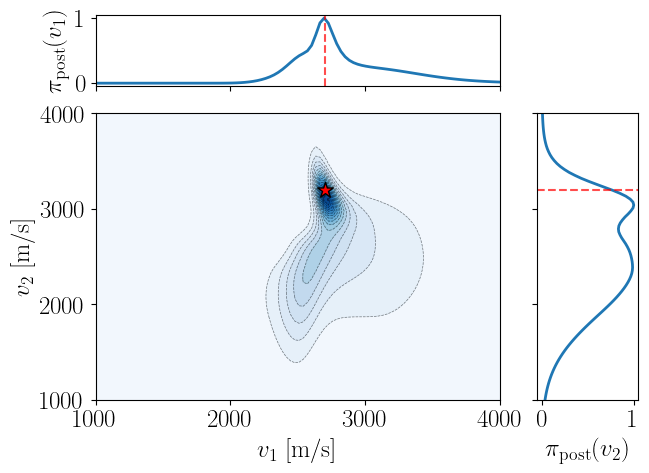

7.610781465276357


In [21]:
logZ = posterior_with_marginals(xgrid, ygrid, LOGPOST, vps[1], vps[2], save_fig=save_figs)
print(logZ)